In [1]:

import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS, HMC
from IPython.core.pylabtools import figsize
import numpy as np
import pandas as pd

from pathlib import Path
import glob
from matplotlib import pyplot as plt
from scipy.stats.mstats import mquantiles



# Parameter determination for function
Data was obtained from a known function. Our goal is to identify the function parameters - here A and B. \
The function is a bi-lorentzian

## Set up function
Here we import the data, define a bi-Lorentzian function and demonstrate the impact of different values of center 1 and center 2 (A and B, respectively) on the simulated spectra.

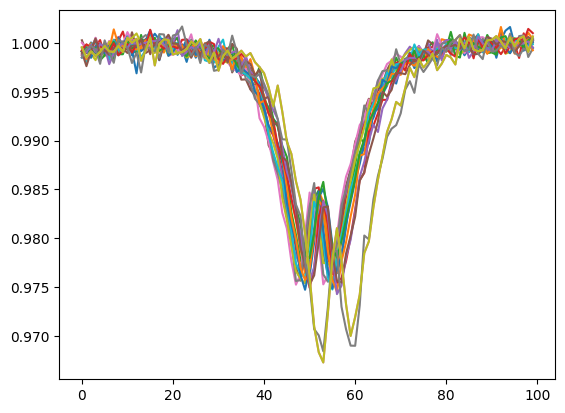

In [5]:
## import data file
fpath = './saved_data/cycle1'

df_= pd.read_csv(fpath, sep=',', header = 0); 
df= df_.iloc[0:, 1:]
df.iloc[:, 1:].plot(legend= False)

# define and scale the frequency axis 
x_esr = df.frequency.values
y_esr = df.iloc[:, 1:]
x_scale = ((x_esr-x_esr.min())/(x_esr.max()-x_esr.min()))*100

torch.set_default_dtype(torch.float64)


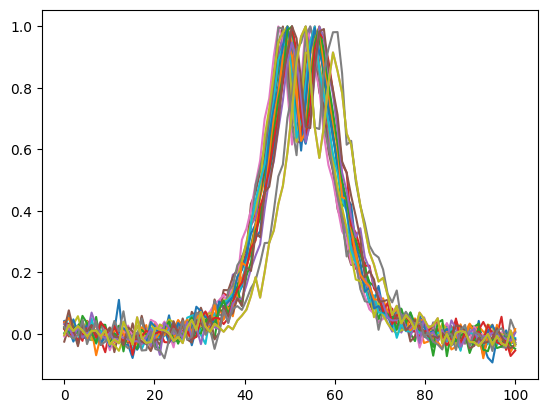

In [6]:
# plot baseline subtracted  y data
y_esr = y_esr.apply(lambda x: x - x[:20].mean())#+0.01
y_esr = -1*y_esr
y_esr = y_esr.apply(lambda x: x/x.max())

plt.plot(x_scale, y_esr);

In [7]:
#numpy version of function
def F_np(x_in, A, X, Amp, G1, G2):
    # Reshape A, B, Amp, G1, G2 for broadcasting with x_in
    A_reshaped = A[None, :]  # Shape (1, num_samples)
    X_reshaped = X[None, :]  # Shape (1, num_samples)
    B_reshaped = A_reshaped + X_reshaped  # Shape (1, num_samples)
    Amp_reshaped = Amp[None, :] # Shape (1, num_samples)
    G1_reshaped = G1[None, :] # New: Reshape gamma1
    G2_reshaped = G2[None, :] # New: Reshape gamma2
    x_in_reshaped = x_in[:, None] # Shape (num_x_points, 1)

    F = (Amp_reshaped) * (0.5 * G1_reshaped) / ((x_in_reshaped - A_reshaped)**2 + (0.5 * G1_reshaped)**2) \
        + (Amp_reshaped) * (0.5 * G2_reshaped) / ((x_in_reshaped - B_reshaped)**2 + (0.5 * G2_reshaped)**2)
    return F


# A function to sample values of A and B and plot resulting function.
def F_samples():
    A = pyro.sample("A", dist.Uniform(40, 57))
    X = pyro.sample("X", dist.Normal(6., 2.0)).double()
    B = A + X
    # Sample gamma1 and gamma2 as pyro variables
    gamma1 = pyro.sample("gamma1_sample", dist.Uniform(1., 7.0)) # Sample gamma1
    gamma2 = pyro.sample("gamma2_sample", dist.Uniform(1., 7.0)) # Sample gamma2

    # Use the sampled gamma values in the function
    f_sim = lambda xi: (amp) *(0.5*gamma1)/((xi-A)**2 + (0.5*gamma1)**2) + (amp) *(0.5*gamma2)/((xi-B)**2 + (0.5*gamma2)**2)
    plt.plot(x_scale, f_sim(x_scale))
    # Update title to show sampled gamma values
    plt.title('A:' + str(A.numpy()) + ' B:' + str(B.numpy()) + ' G1:' + str(gamma1.numpy()) + ' G2:' + str(gamma2.numpy()))



## Define data we will start with and plot.

In [8]:

# this will be the data we'll start with, shown as red circles
def dataslicer(x, y, col1 =1 ,col2=2):
    x_scale_tensor = torch.tensor(x_scale).double()
    # squeeze the selected column to produce a 1-D tensor (N,) instead of (N,1)
    y_vals = y_esr.iloc[:, col1:col2].values.squeeze()
    y_scale_tensor = torch.tensor(y_vals).double()
    return x_scale_tensor, y_scale_tensor



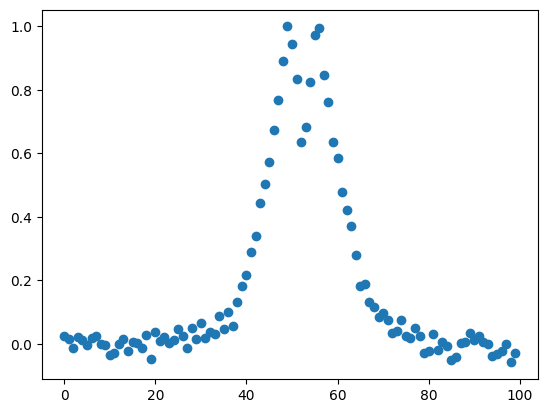

In [9]:
plt.plot(y_esr.iloc[:, 1].values, 'o')
#plt.xlim(40,70)

## Set up and run Bayesian inference

In [18]:
# define the model
# Here we assume that we know the noise variance in the data = 0.1,
# though this can be set to another parameter to learn.

x_obs, y_obs = dataslicer(x_scale, y_esr, col1=0, col2=1)
data = (x_obs.clone().detach().double(), y_obs.clone().detach().double())

def model(data):
    A = pyro.sample("A", dist.Normal(50., 2.0)).double() # sample a value for A uniformly between 0 and 10
    X =  pyro.sample("X", dist.Normal(8., 2.0)).double()
    B = A + X # sample a value for B uniformly between 0 and 10
    gamma1 = pyro.sample("gamma1", dist.Normal(8.0, 2.5)).double()
    gamma2 = gamma1#pyro.sample("gamma2", dist.Normal(6.0, 2.5)).double()
    amp =  pyro.sample("amp", dist.Normal(3.0, 0.25 )).double()
    var = pyro.sample("var", dist.HalfNormal(scale=0.1)).double()

    F =  (amp) * (0.5 * gamma1) / ((data[0] - A)**2 + (0.5 * gamma1)**2) \
        + (amp) * (0.5 * gamma2) / ((data[0] - B)**2 + (0.5 * gamma2)**2)
    # ensure F is a 1-D mean vector matching y_obs
    F = F.squeeze()

    #with pyro.plate("data", data[0].size(0)):
    pyro.sample("obs", dist.MultivariateNormal(F, var * torch.eye(data[1].shape[0]).double()), obs=data[1])

(40.0, 70.0)

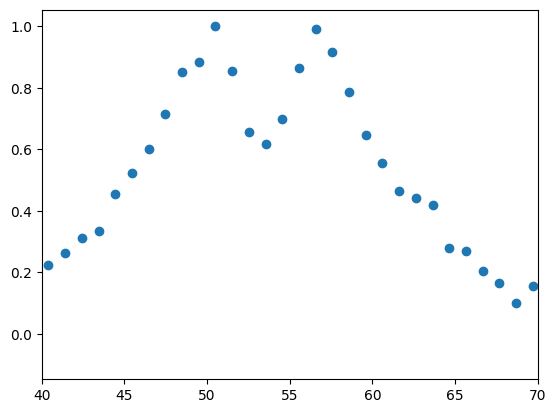

In [19]:
plt.plot(x_obs, y_obs, 'o')
plt.xlim(40, 70)

In [20]:
# solve for the posterior using MCMC
kernel = NUTS(model, jit_compile=True, ignore_jit_warnings=True, max_tree_depth=6)
posterior = MCMC(kernel, num_samples=2000, warmup_steps=2000, num_chains=1)
posterior.run((data))

Sample: 100%|██████████| 4000/4000 [01:17, 51.76it/s, step size=4.70e-01, acc. prob=0.926]


## Get results and plot

(2000,) (2000,) (2000,) (2000,) (2000,) (2000,) (100, 2000) (2, 100) (100,)


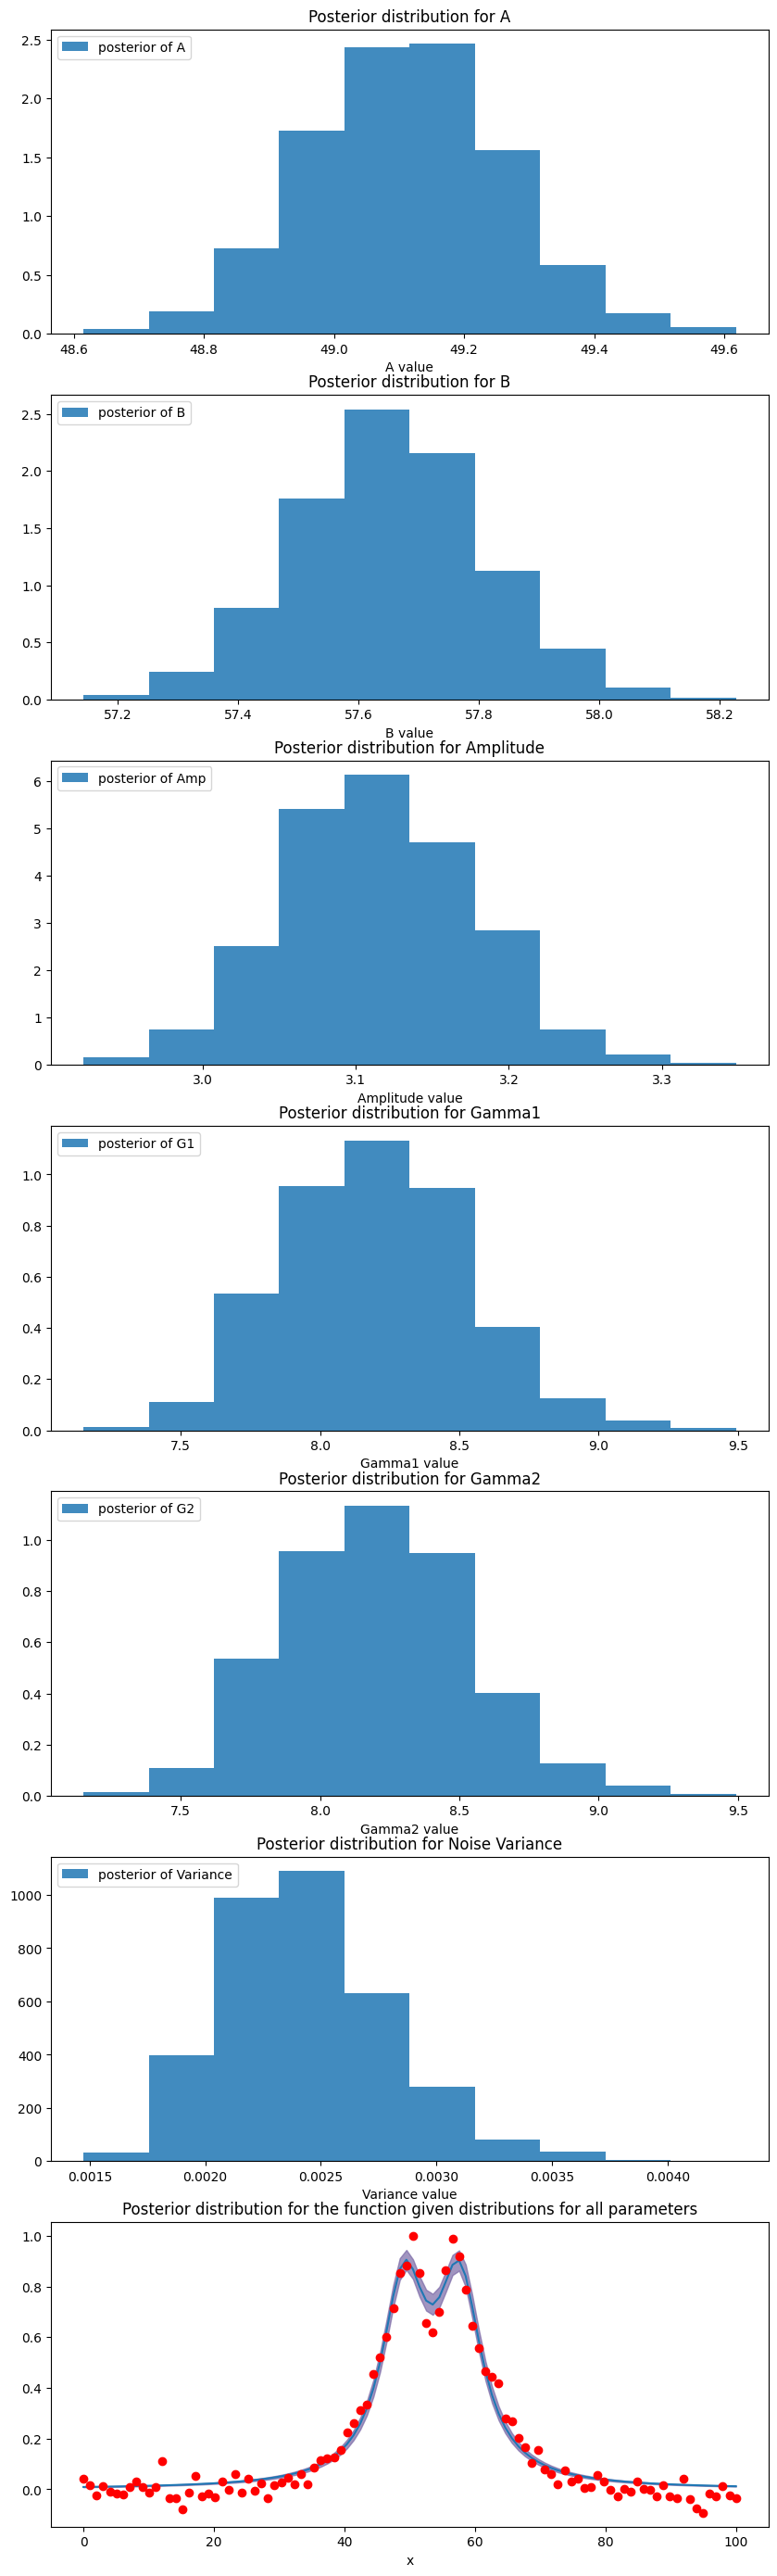

In [21]:
# get the MCMC samples for center A and center B, variance (var), amplitude (amp), and linewidth (gamma1) and plot histogram for each. 
# note gamma1 is used for both peaks in this model.

hmc_samples = {k: v.detach().cpu().numpy() for k, v in posterior.get_samples().items()}
A_ = hmc_samples['A']
X_ = hmc_samples['X']
B_ = A_ + X_
amp_ = hmc_samples['amp'] # Get posterior samples for amp
gamma1_ = hmc_samples['gamma1'] # Get posterior samples for gamma1
gamma2_ = hmc_samples['gamma1'] # Get posterior samples for gamma2 (since gamma2 = gamma1 in the model)
var = hmc_samples['var'] # Get posterior samples for var

# Ensure X_grid_ is a numpy array for F_np calculation and pass amp_ and gamma values
F = F_np(x_scale, A_, X_, amp_, gamma1_, gamma2_)
qs = mquantiles(F.T, [0.025, 0.975], axis=0)
F_mean = F.mean(axis = 1)
print(A_.shape, B_.shape, amp_.shape, gamma1_.shape, gamma2_.shape, var.shape, F.shape, qs.shape, F_mean.shape)

# plot the results

plt.figure(figsize = (10, 35)) # Increased figure size to accommodate new subplots
plt.subplot(7,1,1)
plt.hist(A_, histtype='stepfilled', bins=10, alpha=0.85,
         label="posterior of A", density=True);
plt.legend(loc="upper left");
plt.title('Posterior distribution for A');
plt.xlabel("A value");

plt.subplot(7,1,2)
plt.hist(B_, histtype='stepfilled', bins=10, alpha=0.85,
         label="posterior of B", density=True);
plt.legend(loc="upper left");
plt.title('Posterior distribution for B');
plt.xlabel("B value");

plt.subplot(7,1,3)
plt.hist(amp_, histtype='stepfilled', bins=10, alpha=0.85,
         label="posterior of Amp", density=True);
plt.legend(loc="upper left");
plt.title('Posterior distribution for Amplitude');
plt.xlabel("Amplitude value");

plt.subplot(7,1,4)
plt.hist(gamma1_, histtype='stepfilled', bins=10, alpha=0.85,
         label="posterior of G1", density=True);
plt.legend(loc="upper left");
plt.title('Posterior distribution for Gamma1');
plt.xlabel("Gamma1 value");

plt.subplot(7,1,5)
plt.hist(gamma2_, histtype='stepfilled', bins=10, alpha=0.85,
         label="posterior of G2", density=True);
plt.legend(loc="upper left");
plt.title('Posterior distribution for Gamma2');
plt.xlabel("Gamma2 value");

plt.subplot(7,1,6)
plt.hist(var, histtype='stepfilled', bins=10, alpha=0.85,
         label="posterior of Variance", density=True);
plt.legend(loc="upper left");
plt.title('Posterior distribution for Noise Variance');
plt.xlabel("Variance value");

plt.subplot(7,1,7)
plt.fill_between(x_obs.flatten(), *qs, alpha=0.7, color="#7A68A6");
plt.plot(x_obs, F_mean);
plt.plot(x_obs, y_obs, 'ro');
plt.xlabel('x')
plt.title('Posterior distribution for the function given distributions for all parameters');

In [22]:
# get the MCMC samples for free parameters, rescale them and plot histogram for each.

hmc_samples = {k: v.detach().cpu().numpy() for k, v in posterior.get_samples().items()}
A_ = (((hmc_samples['A'] - hmc_samples['X'])/100) * ((x_esr.max()-x_esr.min()))) + x_esr.min()
X_ = hmc_samples['X']
B_ = (((hmc_samples['A'] + X_)/100) * ((x_esr.max()-x_esr.min()))) + x_esr.min()
amp_ = hmc_samples['amp'] # Get posterior samples for amp
gamma1_ = hmc_samples['gamma1'] # Get posterior samples for gamma1
gamma2_ = hmc_samples['gamma1'] # Get posterior samples for gamma2 (since gamma2 = gamma1 in the model)
var = hmc_samples['var'] # Get posterior samples for var

print(f'the mean A is {np.mean(A_)/1e9:.4f} GHZ with error of {np.std(A_)/1e3:.4f} kHz')
print(f'the mean B is {np.mean(B_)/1e9:.4f} GHz with error of {np.std(B_)/1e3:.4f} kHz')

print(f'the mean error in peak position, A, corresponds to {(np.std(A_)/1e3)/77:.2f} K')
print(f'the mean error in peak position, B, corresponds to {(np.std(B_)/1e3)/77:.2f} K')


the mean A is 2.8553 GHZ with error of 341.0641 kHz
the mean B is 2.8739 GHz with error of 169.4734 kHz
the mean error in peak position, A, corresponds to 4.43 K
the mean error in peak position, B, corresponds to 2.20 K


Here we sample the data, 10 "pixels" at a time. Given the initial guess we fit the sampled spectra each time and estimate the peak centers and the estimated error in peak positions. From the simulation above we know that given the entire spectra we can estimate the peak position with an error of 2.27 K

In [23]:
# clear the optimizer cache
pyro.clear_param_store()       # reset pyro's learned parameters
#svi = SVI(model, guide, optim, loss=Trace_ELBO())  # recreate SVI if needed

Sample: 100%|██████████| 6000/6000 [02:01, 49.46it/s, step size=7.37e-02, acc. prob=0.875]


index is extended to 10
the mean A is 2.8120 GHZ with error of 121.6628 kHz
the mean B is 2.8128 GHz with error of 224.6074 kHz
the mean error in peak position, A, corresponds to 1.58 K
the mean error in peak position, B, corresponds to 2.92 K


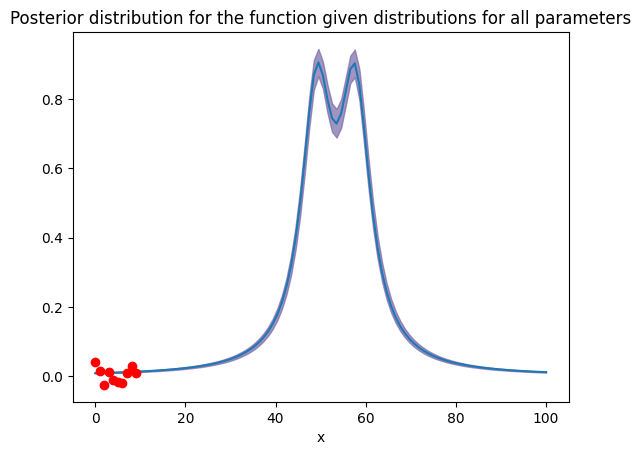

Sample: 100%|██████████| 6000/6000 [01:53, 53.03it/s, step size=1.68e-01, acc. prob=0.716] 


index is extended to 20
the mean A is 2.8120 GHZ with error of 113.1053 kHz
the mean B is 2.8117 GHz with error of 217.6342 kHz
the mean error in peak position, A, corresponds to 1.47 K
the mean error in peak position, B, corresponds to 2.83 K


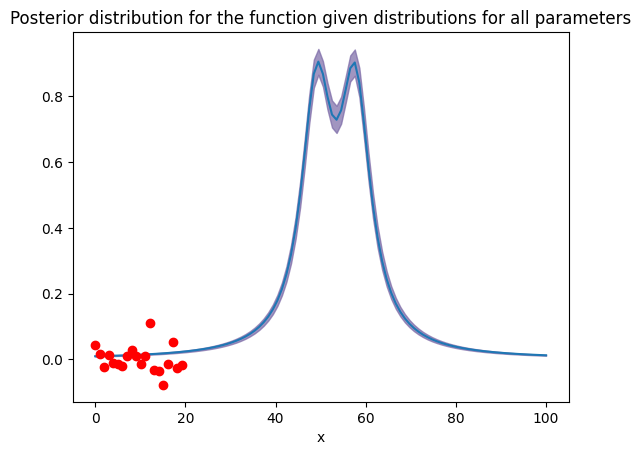

Sample: 100%|██████████| 6000/6000 [01:48, 55.53it/s, step size=6.90e-01, acc. prob=0.906]


index is extended to 30
the mean A is 2.8663 GHZ with error of 2105.6646 kHz
the mean B is 2.8753 GHz with error of 3050.8677 kHz
the mean error in peak position, A, corresponds to 27.35 K
the mean error in peak position, B, corresponds to 39.62 K


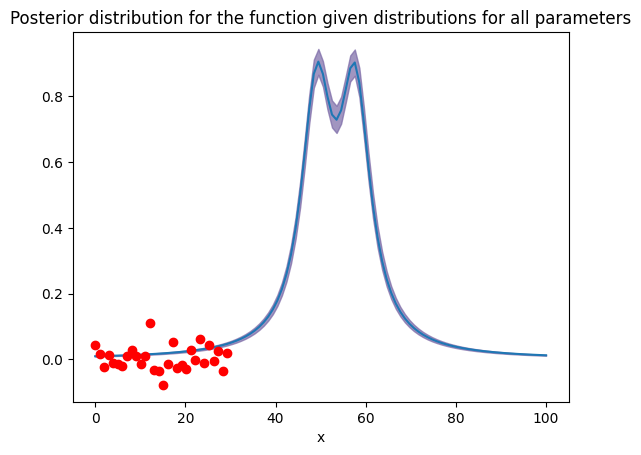

Sample: 100%|██████████| 6000/6000 [01:35, 62.93it/s, step size=2.47e-01, acc. prob=0.583] 


index is extended to 40
the mean A is 2.8131 GHZ with error of 131.8190 kHz
the mean B is 2.8148 GHz with error of 838.8693 kHz
the mean error in peak position, A, corresponds to 1.71 K
the mean error in peak position, B, corresponds to 10.89 K


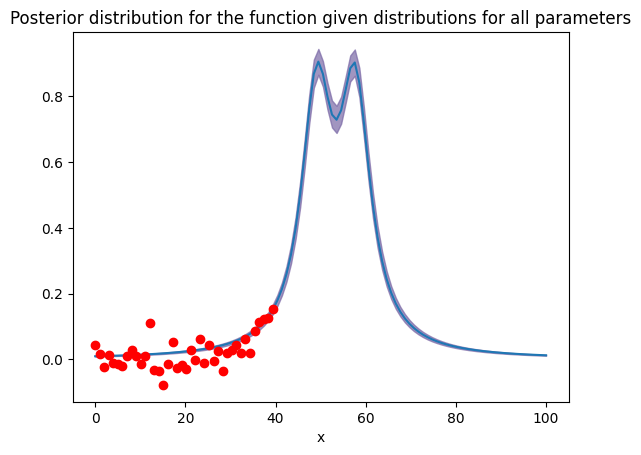

Sample: 100%|██████████| 6000/6000 [01:46, 56.08it/s, step size=1.89e-01, acc. prob=0.751] 


index is extended to 50
the mean A is 2.8109 GHZ with error of 127.4823 kHz
the mean B is 2.8138 GHz with error of 875.7016 kHz
the mean error in peak position, A, corresponds to 1.66 K
the mean error in peak position, B, corresponds to 11.37 K


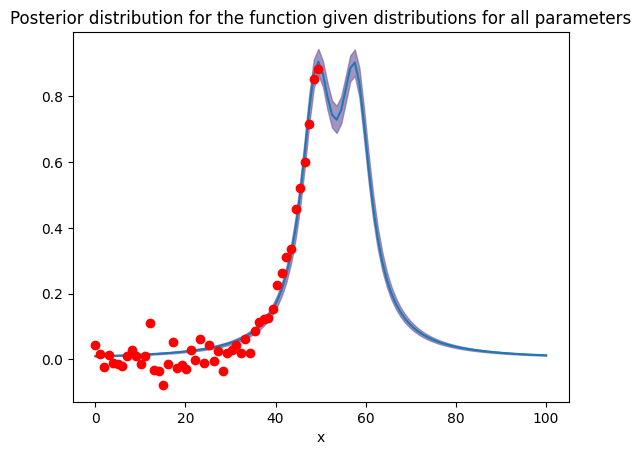

Sample: 100%|██████████| 6000/6000 [01:54, 52.27it/s, step size=4.70e-01, acc. prob=0.912]


index is extended to 60
the mean A is 2.8645 GHZ with error of 169.0311 kHz
the mean B is 2.8736 GHz with error of 210.9329 kHz
the mean error in peak position, A, corresponds to 2.20 K
the mean error in peak position, B, corresponds to 2.74 K


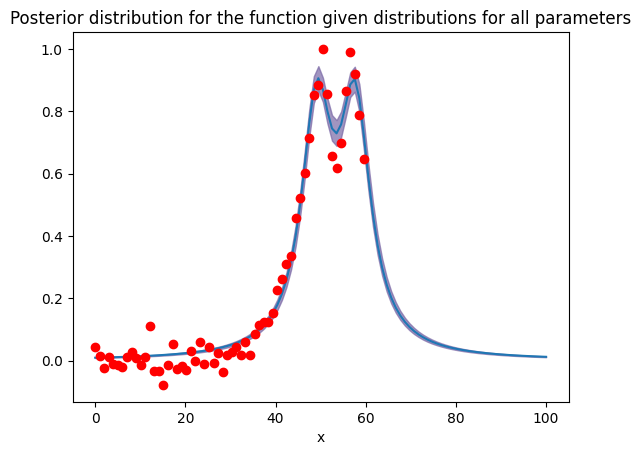

Sample: 100%|██████████| 6000/6000 [02:05, 47.73it/s, step size=5.28e-02, acc. prob=0.888]


index is extended to 70
the mean A is 2.8181 GHZ with error of 740.9743 kHz
the mean B is 2.8195 GHz with error of 218.3413 kHz
the mean error in peak position, A, corresponds to 9.62 K
the mean error in peak position, B, corresponds to 2.84 K


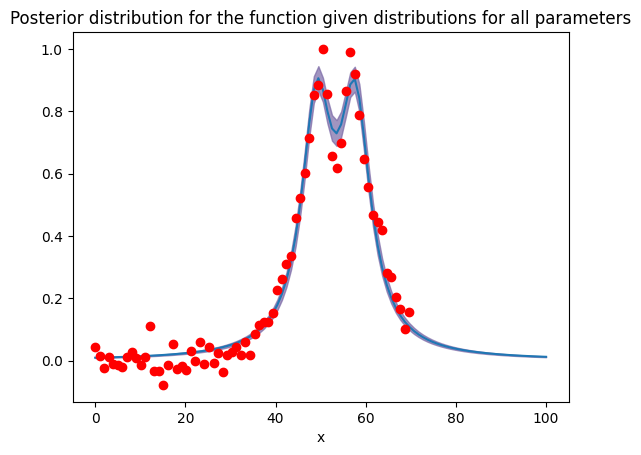

Sample: 100%|██████████| 6000/6000 [02:01, 49.44it/s, step size=4.91e-01, acc. prob=0.926]


index is extended to 80
the mean A is 2.8646 GHZ with error of 166.0139 kHz
the mean B is 2.8739 GHz with error of 166.3352 kHz
the mean error in peak position, A, corresponds to 2.16 K
the mean error in peak position, B, corresponds to 2.16 K


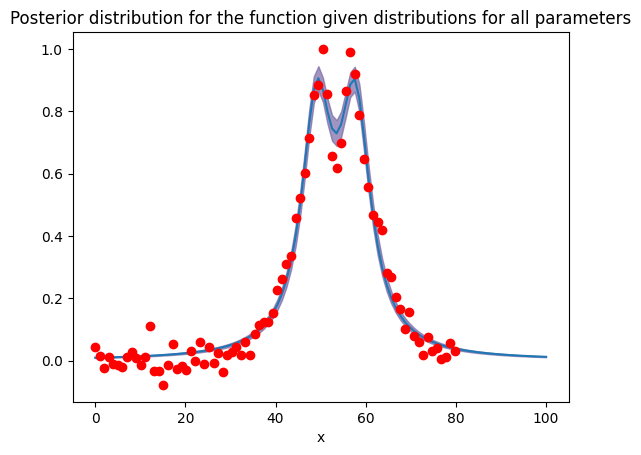

Sample: 100%|██████████| 6000/6000 [01:59, 50.25it/s, step size=1.34e-01, acc. prob=0.883] 


index is extended to 90
the mean A is 2.8131 GHZ with error of 129.2158 kHz
the mean B is 2.8150 GHz with error of 227.8065 kHz
the mean error in peak position, A, corresponds to 1.68 K
the mean error in peak position, B, corresponds to 2.96 K


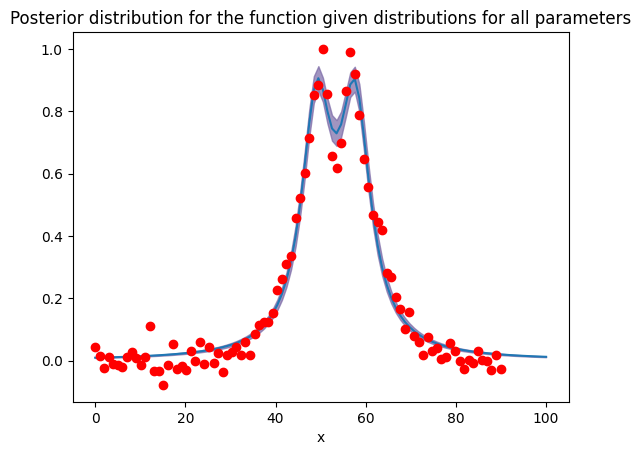

In [24]:
idx = []
error_A = []
error_B = []

for i in range(10, x_esr.shape[0],10):
  x_obs, y_obs = dataslicer(x_scale, y_esr, col1=0, col2=1)
  data = (x_obs[:i].clone().detach().double(), y_obs[:i].clone().detach().double())
  kernel = NUTS(model, jit_compile=True, ignore_jit_warnings=True, max_tree_depth=3)
  posterior = MCMC(kernel, num_samples=5000, warmup_steps=1000, num_chains=1)
  posterior.run(data);

  hmc_samples = {k: v.detach().cpu().numpy() for k, v in posterior.get_samples().items()}
  A_ = ((hmc_samples['A']/100) * ((x_esr.max()-x_esr.min()))) + x_esr.min()
  X_ = hmc_samples['X']
  B_ = (((hmc_samples['A'] + X_)/100) * ((x_esr.max()-x_esr.min()))) + x_esr.min()
  amp_ = hmc_samples['amp'] # Get posterior samples for amp
  gamma1_ = hmc_samples['gamma1'] # Get posterior samples for gamma1
  gamma2_ = hmc_samples['gamma1'] # Get posterior samples for gamma2 (since gamma2 = gamma1 in the model)
  var = hmc_samples['var'] # Get posterior samples for var
  idx.append(i)
  error_A.append((np.std(A_)/1e3)/77)
  error_B.append((np.std(B_)/1e3)/77)
  print(f'index is extended to {i}')
  print(f'the mean A is {np.mean(A_)/1e9:.4f} GHZ with error of {np.std(A_)/1e3:.4f} kHz')
  print(f'the mean B is {np.mean(B_)/1e9:.4f} GHz with error of {np.std(B_)/1e3:.4f} kHz')

  print(f'the mean error in peak position, A, corresponds to {(np.std(A_)/1e3)/77:.2f} K')
  print(f'the mean error in peak position, B, corresponds to {(np.std(B_)/1e3)/77:.2f} K')
  plt.fill_between(x_scale.flatten(), *qs, alpha=0.7, color="#7A68A6");
  plt.plot(x_scale, F_mean);
  plt.plot(x_obs[:i], y_obs[:i], 'ro');
  plt.xlabel('x')
  plt.title('Posterior distribution for the function given distributions for all parameters');plt.show()
  pyro.clear_param_store()       # reset pyro's learned parameters
  #svi = SVI(model, guide, optim, loss=Trace_ELBO())  # recreate SVI if needed


Text(0, 0.5, 'error in peak center estimation (K)')

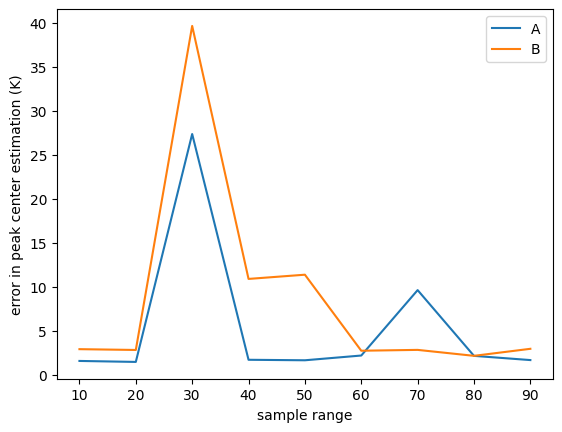

In [25]:
plt.plot(idx, error_A, label = 'error in A')
plt.plot(idx, error_B, label = 'error in B')
plt.legend(['A', 'B'])
plt.xlabel('sample range')
plt.ylabel('error in peak center estimation (K)')

Here we examine what happens if we decrease our data density i.e reduce the resolution of the measurement

Sample: 100%|██████████| 6000/6000 [01:39, 60.33it/s, step size=2.79e-01, acc. prob=0.671] 


#################
every 10th frequency is being sampled


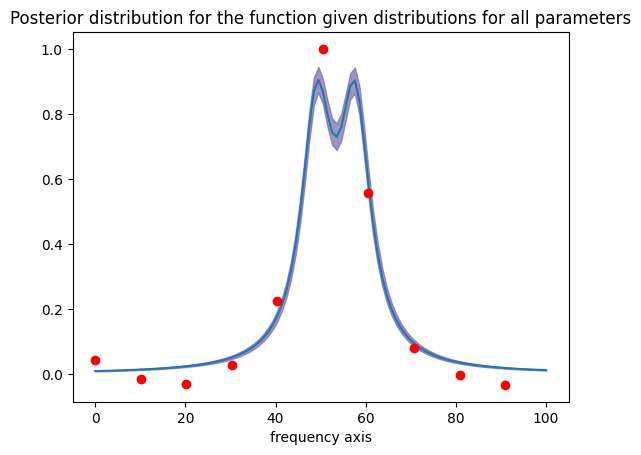

the mean A is 2.8218 GHZ with error of 184.8993 kHz
the mean B is 2.8307 GHz with error of 2705.4960 kHz
the mean error in peak position, A, corresponds to 2.40 K
the mean error in peak position, B, corresponds to 35.14 K
################# fin ##########


Sample: 100%|██████████| 6000/6000 [01:48, 55.20it/s, step size=1.46e-01, acc. prob=0.843] 


#################
every 9th frequency is being sampled


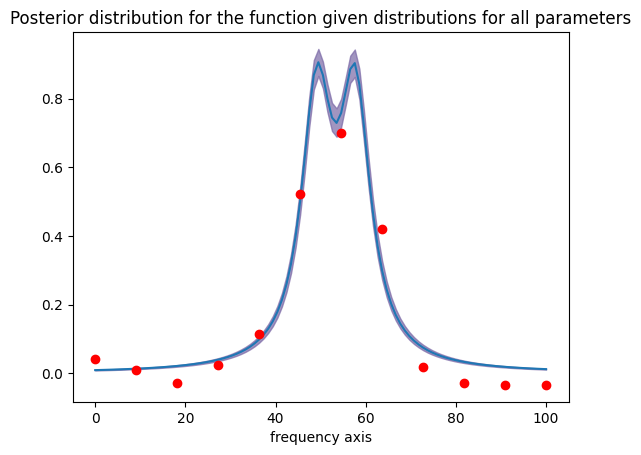

the mean A is 2.8207 GHZ with error of 193.8186 kHz
the mean B is 2.8289 GHz with error of 2097.0402 kHz
the mean error in peak position, A, corresponds to 2.52 K
the mean error in peak position, B, corresponds to 27.23 K
################# fin ##########


Sample: 100%|██████████| 6000/6000 [01:53, 52.86it/s, step size=3.07e-01, acc. prob=0.878]


#################
every 8th frequency is being sampled


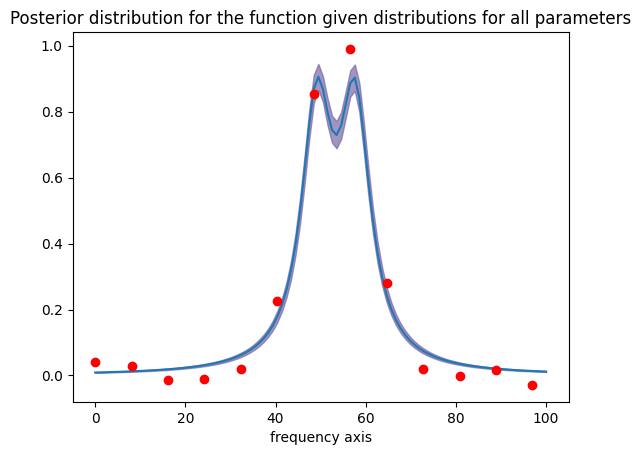

the mean A is 2.8649 GHZ with error of 1177.3503 kHz
the mean B is 2.8734 GHz with error of 830.1755 kHz
the mean error in peak position, A, corresponds to 15.29 K
the mean error in peak position, B, corresponds to 10.78 K
################# fin ##########


Sample: 100%|██████████| 6000/6000 [01:52, 53.48it/s, step size=1.32e-01, acc. prob=0.926] 


#################
every 7th frequency is being sampled


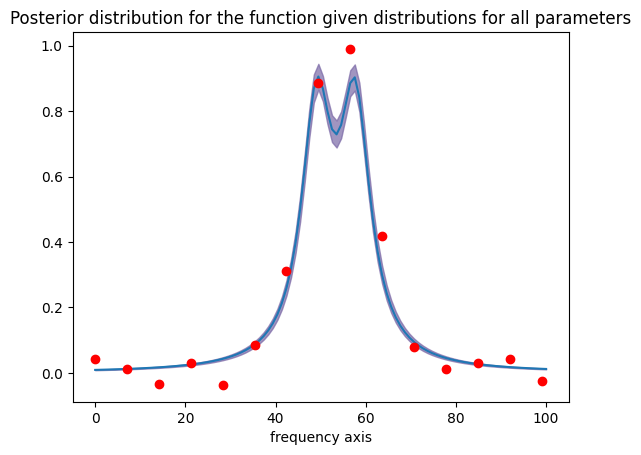

the mean A is 2.8185 GHZ with error of 160.9477 kHz
the mean B is 2.8272 GHz with error of 4224.7294 kHz
the mean error in peak position, A, corresponds to 2.09 K
the mean error in peak position, B, corresponds to 54.87 K
################# fin ##########


Sample: 100%|██████████| 6000/6000 [01:50, 54.19it/s, step size=1.35e-01, acc. prob=0.857] 


#################
every 6th frequency is being sampled


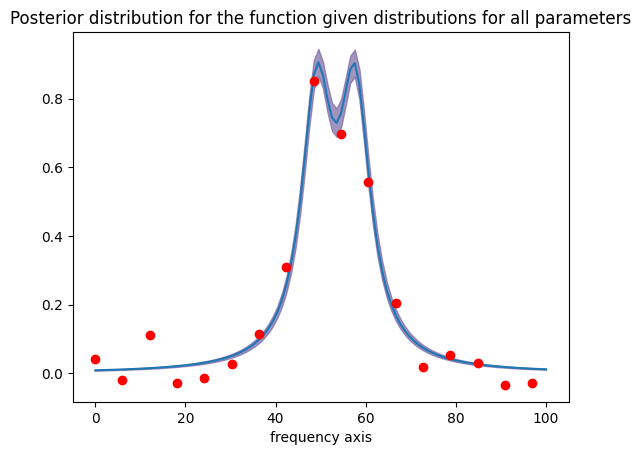

the mean A is 2.8108 GHZ with error of 144.1772 kHz
the mean B is 2.8159 GHz with error of 4365.1777 kHz
the mean error in peak position, A, corresponds to 1.87 K
the mean error in peak position, B, corresponds to 56.69 K
################# fin ##########


Sample: 100%|██████████| 6000/6000 [01:44, 57.65it/s, step size=1.64e-01, acc. prob=0.794]


#################
every 5th frequency is being sampled


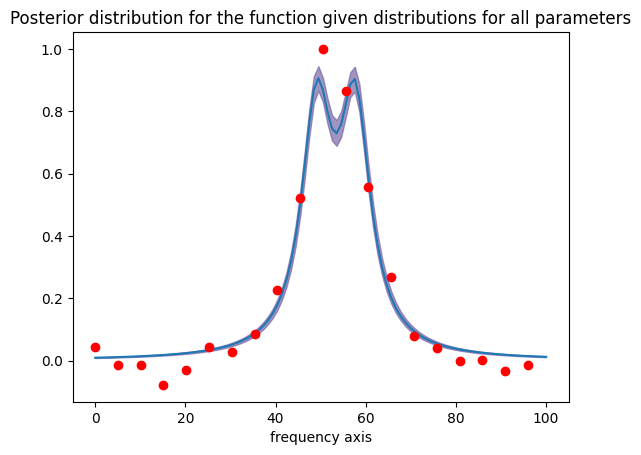

the mean A is 2.8272 GHZ with error of 176.0161 kHz
the mean B is 2.8358 GHz with error of 2020.8419 kHz
the mean error in peak position, A, corresponds to 2.29 K
the mean error in peak position, B, corresponds to 26.24 K
################# fin ##########


Sample: 100%|██████████| 6000/6000 [01:35, 62.57it/s, step size=1.84e-01, acc. prob=0.682] 


#################
every 4th frequency is being sampled


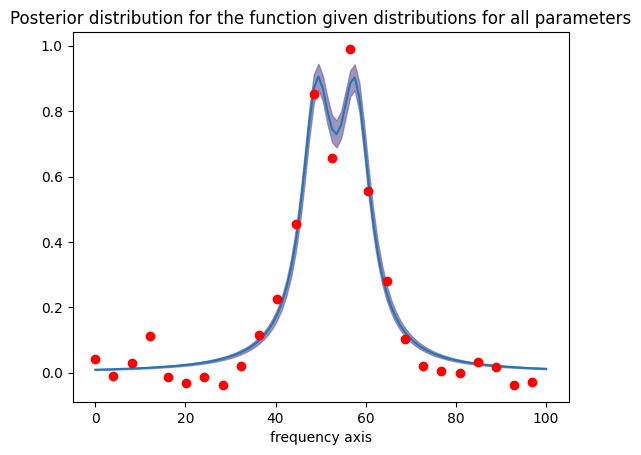

the mean A is 2.8153 GHZ with error of 151.4103 kHz
the mean B is 2.8240 GHz with error of 2136.7549 kHz
the mean error in peak position, A, corresponds to 1.97 K
the mean error in peak position, B, corresponds to 27.75 K
################# fin ##########


Sample: 100%|██████████| 6000/6000 [01:49, 54.84it/s, step size=1.44e-01, acc. prob=0.783] 


#################
every 3th frequency is being sampled


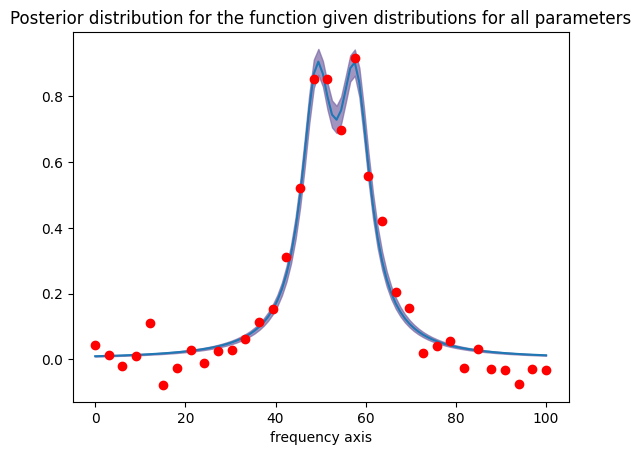

the mean A is 2.8174 GHZ with error of 181.1444 kHz
the mean B is 2.8231 GHz with error of 717.0776 kHz
the mean error in peak position, A, corresponds to 2.35 K
the mean error in peak position, B, corresponds to 9.31 K
################# fin ##########


Sample: 100%|██████████| 6000/6000 [01:48, 55.38it/s, step size=1.60e-01, acc. prob=0.798] 


#################
every 2th frequency is being sampled


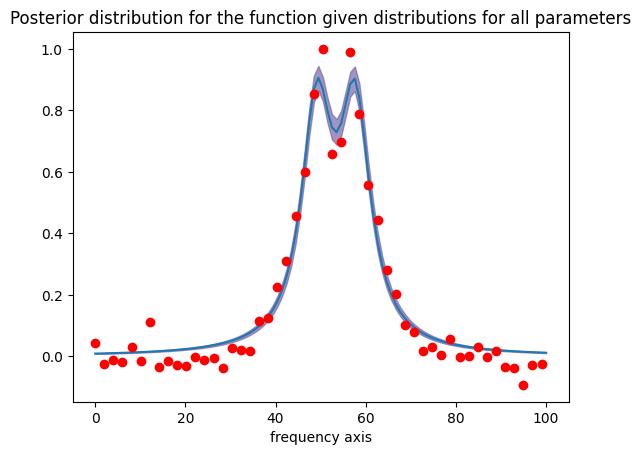

the mean A is 2.8152 GHZ with error of 173.1971 kHz
the mean B is 2.8151 GHz with error of 1936.9087 kHz
the mean error in peak position, A, corresponds to 2.25 K
the mean error in peak position, B, corresponds to 25.15 K
################# fin ##########


Sample: 100%|██████████| 6000/6000 [02:06, 47.46it/s, step size=5.32e-02, acc. prob=0.967]


#################
every 1th frequency is being sampled


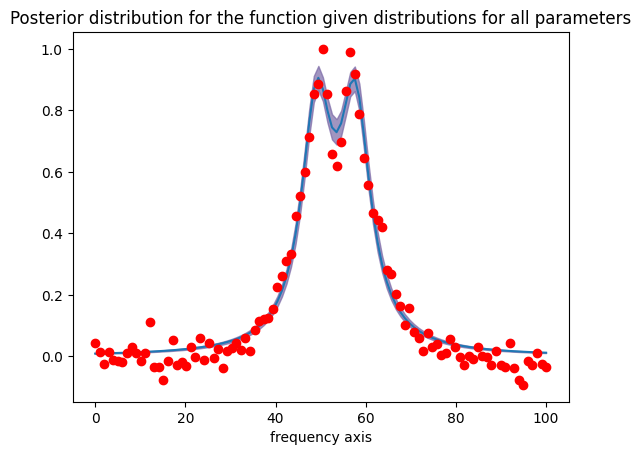

the mean A is 2.8109 GHZ with error of 124.2329 kHz
the mean B is 2.8103 GHz with error of 534.6133 kHz
the mean error in peak position, A, corresponds to 1.61 K
the mean error in peak position, B, corresponds to 6.94 K
################# fin ##########


In [26]:
idx = []
error_A = []
error_B = []

for j in range(0, 10):  # Changed range to start from 1
  i = 10-j
  x_obs, y_obs = dataslicer(x_scale, y_esr, col1=0, col2=1)
  data = (x_obs[::i].clone().detach().double(), y_obs[::i].clone().detach().double())
  kernel = NUTS(model, jit_compile=True, ignore_jit_warnings=True, max_tree_depth=3)
  posterior = MCMC(kernel, num_samples=5000, warmup_steps=1000, num_chains=1)
  posterior.run(data);

  hmc_samples = {k: v.detach().cpu().numpy() for k, v in posterior.get_samples().items()}
  X_ = hmc_samples['X']
  B_ = (((hmc_samples['A'] + X_)/100) * ((x_esr.max()-x_esr.min()))) + x_esr.min()
  A_ = (((hmc_samples['A'])/100) * ((x_esr.max()-x_esr.min()))) + x_esr.min()
  amp_ = hmc_samples['amp'] # Get posterior samples for amp
  gamma1_ = hmc_samples['gamma1'] # Get posterior samples for gamma1
  gamma2_ = hmc_samples['gamma1'] # Get posterior samples for gamma2 (since gamma2 = gamma1 in the model)
  var = hmc_samples['var'] # Get posterior samples for var
  idx.append(i)
  error_A.append((np.std(A_)/1e3)/77)
  error_B.append((np.std(B_)/1e3)/77)
  print('#################')
  print(f'every {i}th frequency is being sampled')
  plt.fill_between(x_scale.flatten(), *qs, alpha=0.7, color="#7A68A6");
  plt.plot(x_scale, F_mean);
  plt.plot(x_obs[::i], y_obs[::i], 'ro'); # Changed plotting slice to reflect data
  plt.xlabel('frequency axis')
  plt.title('Posterior distribution for the function given distributions for all parameters');plt.show()
  print(f'the mean A is {np.mean(A_)/1e9:.4f} GHZ with error of {np.std(A_)/1e3:.4f} kHz')
  print(f'the mean B is {np.mean(B_)/1e9:.4f} GHz with error of {np.std(B_)/1e3:.4f} kHz')
  print(f'the mean error in peak position, A, corresponds to {(np.std(A_)/1e3)/77:.2f} K')
  print(f'the mean error in peak position, B, corresponds to {(np.std(B_)/1e3)/77:.2f} K')
  print('################# fin ##########')
  pyro.clear_param_store()       # reset pyro's learned parameters
  #svi = SVI(model, guide, optim, loss=Trace_ELBO())  # recreate SVI if needed

Text(0, 0.5, 'error in peak center estimation (K)')

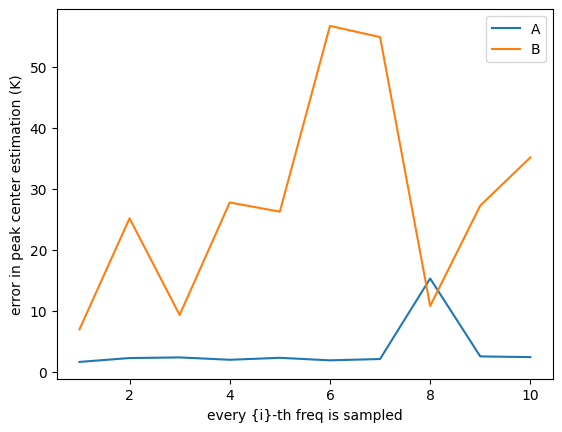

In [27]:
plt.plot(idx, error_A, label = 'error in A')
plt.plot(idx, error_B, label = 'error in B')
plt.legend(['A', 'B'])
plt.xlabel('every {i}-th freq is sampled')
plt.ylabel('error in peak center estimation (K)')